### import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


#### Data Science ####
                                # Part 1 #

In [3]:
#import the csv files

items = pd.read_csv('/items.csv')
resturants = pd.read_csv('/resturants.csv')
sales = pd.read_csv('/sales.csv')

In [4]:
 # print the files

print('\n\n items.csv:\n', items)
print('\n\n resturants.csv: \n',resturants)
print('\n\n sales.csv: \n',sales)




 items.csv:
      id  store_id                                               name  kcal  \
0     1         4                                     Chocolate Cake   554   
1     2         4                  Breaded Fish with Vegetables Meal   772   
2     3         1                                  Sweet Fruity Cake   931   
3     4         1                    Amazing Steak Dinner with Rolls   763   
4     5         5                                          Milk Cake   583   
..  ...       ...                                                ...   ...   
95   96         5                  Blue Ribbon Fish with Bread Lunch   708   
96   97         4  Original Fruity Cod with Bread and Vegetables ...   744   
97   98         2                    Original Sweet Milky Soft Drink   579   
98   99         4                           Frozen Tomato Soft Drink   423   
99  100         2                             Awesome Vodka Cocktail   223   

     cost  
0    6.71  
1   15.09  
2   29.22  


In [5]:
# print the shape of the files
print("Shape of items.csv:", items.shape)
print("Shape of resturants.csv:", resturants.shape)
print("Shape of sales.csv:", sales.shape)

Shape of items.csv: (100, 5)
Shape of resturants.csv: (6, 2)
Shape of sales.csv: (109600, 4)


In [6]:
# list the columns of sales.csv
columns = sales.columns.tolist()
print('\n\n colums of sales.csv:', columns)



 colums of sales.csv: ['date', 'item_id', 'price', 'item_count']


In [7]:
# outlier calculation for items.csv
columns_to_select = ['kcal', 'cost']

for col in columns_to_select:
       Q1 = items[col].quantile(0.25)
       Q3 = items[col].quantile(0.75)
       IQR = Q3 - Q1

       lower_bound = Q1 - 1.5 * IQR
       upper_bound = Q3 + 1.5 * IQR

       outliers = items[(items[col] < lower_bound) | (items[col] > upper_bound)]
       print(f"\n\nOutliers of items.csv[{col}]:\n", outliers)


# outlier calculation for sales.csv
columns_to_select = ['price', 'item_count']

for col in columns_to_select:
       Q1 = sales[col].quantile(0.25)
       Q3 = sales[col].quantile(0.75)
       IQR = Q3 - Q1

       lower_bound = Q1 - 1.5 * IQR
       upper_bound = Q3 + 1.5 * IQR

       outliers = sales[(sales[col] < lower_bound) | (sales[col] > upper_bound)]
       print(f"\n\nOutliers of sales.csv[{col}]:\n", outliers)



Outliers of items.csv[kcal]:
     id  store_id                                          name  kcal  cost
32  33         6  Original Breaded Pork with Vegetables Dinner  1023  20.8


Outliers of items.csv[cost]:
     id  store_id                           name  kcal   cost
79  80         4  Blue Ribbon Fruity Vegi Lunch   881  53.98


Outliers of sales.csv[price]:
               date  item_id  price  item_count
82      2019-01-01       80  53.98         0.0
115     2019-01-02       80  53.98         2.0
216     2019-01-03       80  53.98         2.0
316     2019-01-04       80  53.98         1.0
482     2019-01-05       80  53.98         0.0
...            ...      ...    ...         ...
109119  2021-12-27       80  53.98         1.0
109280  2021-12-28       80  53.98         0.0
109379  2021-12-29       80  53.98         0.0
109480  2021-12-30       80  53.98         0.0
109580  2021-12-31       80  53.98         0.0

[1096 rows x 4 columns]


Outliers of sales.csv[item_count]:
     

In [8]:
# rename the id column of items.csv
items.rename(columns={'id': 'item_id'}, inplace=True)

# Merge sales with items on item_id
merged_data = pd.merge(sales, items, on='item_id', how='left')

# rename the id column of resturants.csv
resturants.rename(columns={'id': 'store_id'}, inplace=True)

 # Merge sales with items on item_id
merged_data = pd.merge(merged_data, resturants, on='store_id', how='left')

# Save to new CSV
merged_data.to_csv('/merged_dataset.csv', index=False)

                    # Part 2 #



         date  total_sales
0 2019-01-01      4023.00
1 2019-01-02      3074.69
2 2019-01-03      4062.71
3 2019-01-04      5006.81
4 2019-01-05      4927.53


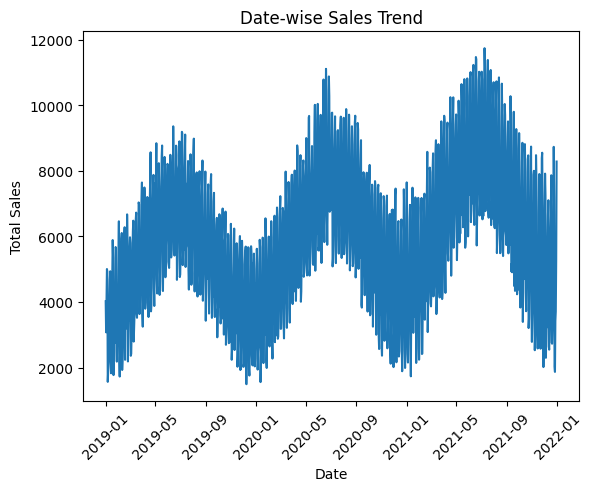

In [9]:

# Step 1- Convert date column to datetime
merged_data['date'] = pd.to_datetime(merged_data['date'])

# Step 2- Create total sales column
merged_data['total_sales'] = merged_data['price'] * merged_data['item_count']

# Step 3- Calculate Date-wise Sales
date_sales = merged_data.groupby('date')['total_sales'].sum().reset_index()

print('\n\n',date_sales.head())

# Step 4- Plot Sales Trend
plt.figure()
plt.plot(date_sales['date'], date_sales['total_sales'])
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Date-wise Sales Trend")
plt.xticks(rotation=45)
plt.show()



weekday_sales:   day_of_week  total_sales
0      Friday   1257338.16
1      Monday    644799.97
2    Saturday   1250574.32
3      Sunday    630279.71
4    Thursday   1073534.52
5     Tuesday    734598.46
6   Wednesday    812613.31


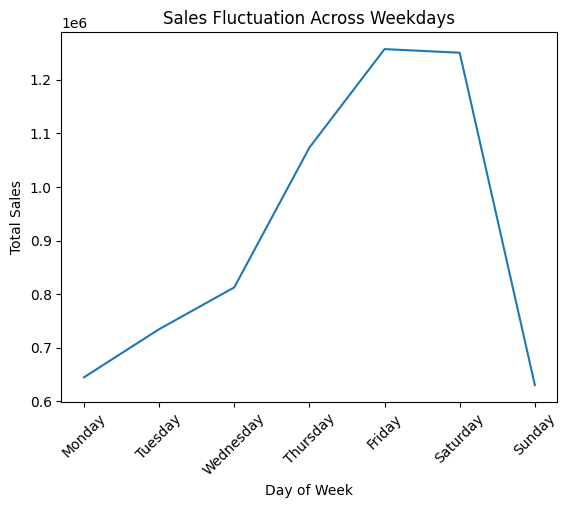

In [10]:
# Find out how sales fluctuate across different days of the week

# Step 1- Extract Day of Week
merged_data['day_of_week'] = merged_data['date'].dt.day_name()

# Step 2- Group by Day of Week
weekday_sales = merged_data.groupby('day_of_week')['total_sales'].sum().reset_index()

print('\n\nweekday_sales:',weekday_sales)

# Step 3- Sort in Proper Week Order
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
         'Friday', 'Saturday', 'Sunday']

weekday_sales['day_of_week'] = pd.Categorical(
    weekday_sales['day_of_week'],
    categories=order,
    ordered=True
    )

weekday_sales = weekday_sales.sort_values('day_of_week')

# Step 4- Plot Weekly Sales Pattern
plt.figure()
plt.plot(weekday_sales['day_of_week'], weekday_sales['total_sales'])
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.title("Sales Fluctuation Across Weekdays")
plt.xticks(rotation=45)
plt.show()

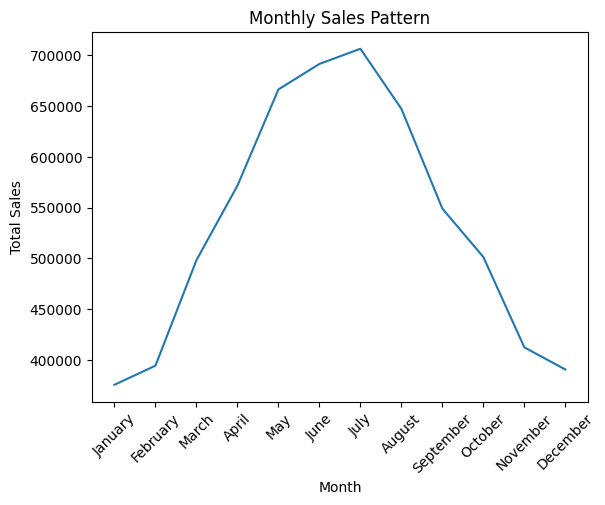

In [11]:
# Look for any noticeable trends in the sales data for different months of the year
# step 1- Extract Month

merged_data['month'] = merged_data['date'].dt.month
merged_data['month_name'] = merged_data['date'].dt.month_name()

# step 2- Group by Month
monthly_sales_named = merged_data.groupby('month_name')['total_sales'].sum().reset_index()

# step- 3 Sort months correctly
order = ['January', 'February', 'March', 'April', 'May', 'June',
         'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales_named['month_name'] = pd.Categorical(
        monthly_sales_named['month_name'],
        categories=order,
        ordered=True
    )

monthly_sales_named = monthly_sales_named.sort_values('month_name')

plt.figure()
plt.plot(monthly_sales_named['month_name'], monthly_sales_named['total_sales'])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Pattern")
plt.show()



    quarter  total_sales
0        1   1268524.29
1        2   1928637.62
2        3   1901991.15
3        4   1304585.39


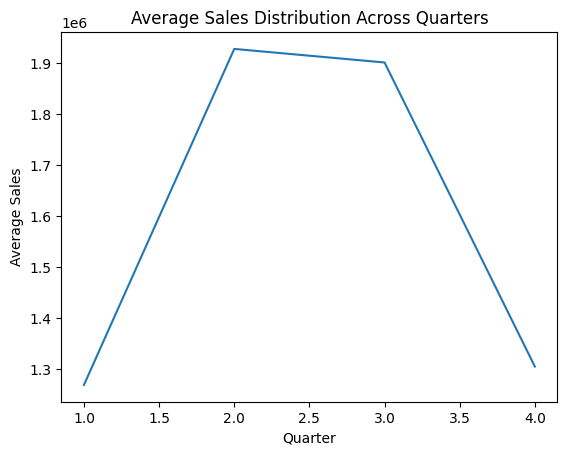

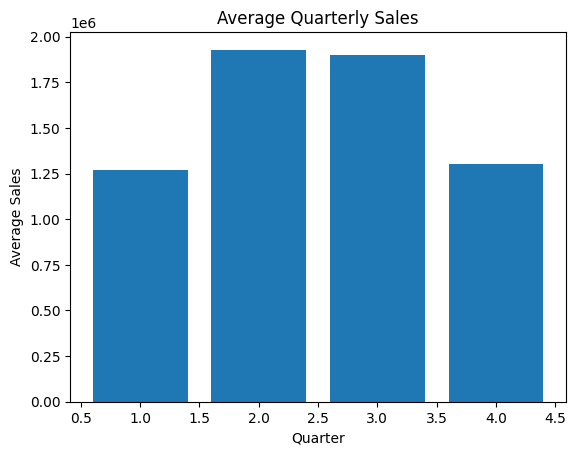

In [12]:
# Examine the sales distribution across different quarters averaged over the years. Identify any noticeable patterns
# step 1: Extract year and Quarter

# merged_data['year'] = merged_data['date'].dt.year
merged_data['quarter'] = merged_data['date'].dt.quarter

# step 2: Calculate Quarterly Sales Per Year
quarterly_sales = merged_data.groupby(['quarter'])['total_sales'].sum().reset_index()

# step 3: Average Across Years
quarterly_avg = quarterly_sales.groupby('quarter')['total_sales'].mean().reset_index()

print('\n\n',quarterly_avg)

# step 4: Plot Quarterly Distribution
plt.figure()
plt.plot(quarterly_avg['quarter'], quarterly_avg['total_sales'])
plt.xlabel("Quarter")
plt.ylabel("Average Sales")
plt.title("Average Sales Distribution Across Quarters")
plt.show()

# Bar Chart
plt.figure()
plt.bar(quarterly_avg['quarter'], quarterly_avg['total_sales'])
plt.xlabel("Quarter")
plt.ylabel("Average Sales")
plt.title("Average Quarterly Sales")
plt.show()



            name_y  total_sales
1     Bob's Diner   6337275.69
3        Fou Cher     27885.37
2     Corner Cafe     16551.43
4        Surfs Up     15651.49
0  Beachfront Bar      3796.20
5     Sweet Shack      2578.27


 Top Restaurant:
name_y         Bob's Diner
total_sales     6337275.69
Name: 1, dtype: object


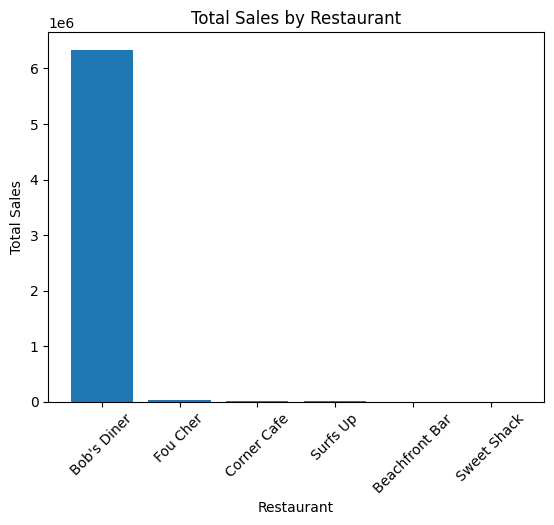



 yearly sales:              name_y  year  total_sales
0   Beachfront Bar  2019      1281.85
1   Beachfront Bar  2020      1267.21
2   Beachfront Bar  2021      1247.14
3      Bob's Diner  2019   1849483.49
4      Bob's Diner  2020   2112331.91
5      Bob's Diner  2021   2375460.29
6      Corner Cafe  2019      5292.93
7      Corner Cafe  2020      5347.71
8      Corner Cafe  2021      5910.79
9         Fou Cher  2019      9698.80
10        Fou Cher  2020      8590.87
11        Fou Cher  2021      9595.70
12        Surfs Up  2019      5132.65
13        Surfs Up  2020      5314.43
14        Surfs Up  2021      5204.41
15     Sweet Shack  2019       872.59
16     Sweet Shack  2020       828.65
17     Sweet Shack  2021       877.03


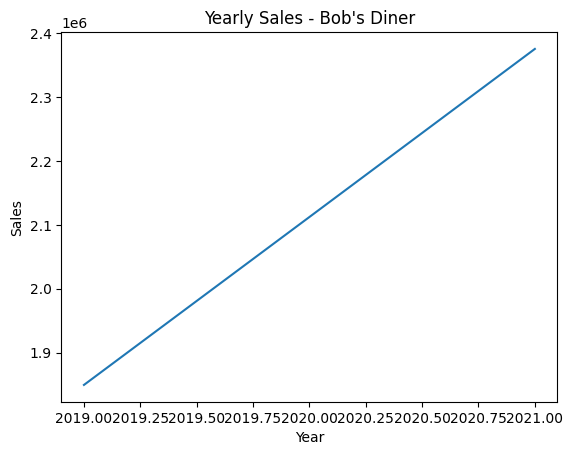



             name_y  month  total_sales
0  Beachfront Bar      1       315.55
1  Beachfront Bar      2       318.10
2  Beachfront Bar      3       340.23
3  Beachfront Bar      4       317.58
4  Beachfront Bar      5       332.64


            name_y       day  total_sales
0  Beachfront Bar    Friday       508.79
1  Beachfront Bar    Monday       544.78
2  Beachfront Bar  Saturday       538.93
3  Beachfront Bar    Sunday       523.11
4  Beachfront Bar  Thursday       518.58


In [13]:
# Compare the performances of the different restaurants. Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days

# step 1 - Restaurant With Most Sales
restaurant_sales = merged_data.groupby('name_y')['total_sales'].sum().reset_index()

# Sort descending
restaurant_sales = restaurant_sales.sort_values('total_sales', ascending=False)

print('\n\n',restaurant_sales)

# Highest Performing Restaurant
print("\n\n Top Restaurant:")
print(restaurant_sales.iloc[0])


# Plot Overall Restaurant Performance
plt.figure()
plt.bar(restaurant_sales['name_y'], restaurant_sales['total_sales'])
plt.xticks(rotation=45)
plt.xlabel("Restaurant")
plt.ylabel("Total Sales")
plt.title("Total Sales by Restaurant")
plt.show()


# step- 2: Sales Across Different Years
merged_data['year'] = merged_data['date'].dt.year

yearly_sales = merged_data.groupby(['name_y', 'year'])['total_sales'].sum().reset_index()

print('\n\n yearly sales: ',yearly_sales)


# Plot Example (One Restaurant at a Time)
restaurant_name = restaurant_sales.iloc[0]['name_y']

data = yearly_sales[yearly_sales['name_y'] == restaurant_name]

plt.figure()
plt.plot(data['year'], data['total_sales'])
plt.xlabel("Year")
plt.ylabel("Sales")
plt.title(f"Yearly Sales - {restaurant_name}")
plt.show()


# step 3: Sales Across Months
merged_data['month'] = merged_data['date'].dt.month

monthly_sales = merged_data.groupby(['name_y', 'month'])['total_sales'].sum().reset_index()

print('\n\n ',monthly_sales.head())


# step 4: Sales Across Days of Week
merged_data['day'] = merged_data['date'].dt.day_name()

weekday_sales = merged_data.groupby(['name_y', 'day'])['total_sales'].sum().reset_index()

print('\n\n',weekday_sales.head())

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
         'Friday', 'Saturday', 'Sunday']

weekday_sales['day'] = pd.Categorical(
        weekday_sales['day'],
        categories=order,
        ordered=True
    )

weekday_sales = weekday_sales.sort_values('day')


#### Machine Learning #####

                        # Part 1 #




 most poular items:                   name_x  item_count
85    Strawberry Smoothy    236337.0
46  Frozen Milky Smoothy    103263.0
9     Amazing pork lunch     61043.0
64         Mutton Dinner     52772.0
67          Orange Juice     43874.0


 most poular items and store:                               name_x       name_y  item_count
91               Strawberry Smoothy  Bob's Diner    236337.0
47             Frozen Milky Smoothy  Bob's Diner    102990.0
9                Amazing pork lunch  Bob's Diner     61043.0
68                    Mutton Dinner  Bob's Diner     52772.0
71                     Orange Juice  Bob's Diner     43874.0
22          Blue Ribbon Beef Entree  Bob's Diner     42774.0
4   Amazing Steak Dinner with Rolls  Bob's Diner     34439.0
94          Sweet Frozen Soft Drink  Bob's Diner     27490.0
89  Sea Bass with Vegetables Dinner  Bob's Diner     23839.0
96                  Sweet Lamb Cake  Bob's Diner     18764.0


 top_item_per_store:             name_y           

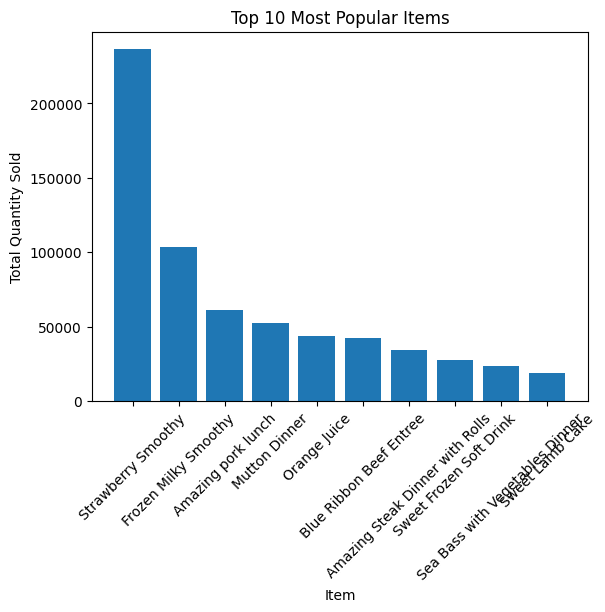

In [14]:
# Identify the most popular items overall and the stores where they are being sold. Also, findout the most popular item at each store

# step 1- Most Popular Items Overall
popular_items = merged_data.groupby('name_x')['item_count'].sum().reset_index()

# step 2- Sort descending
popular_items = popular_items.sort_values('item_count', ascending=False)

print('\n\n most poular items:',popular_items.head())

# step 3 - Stores Where These Items Are Sold
item_store_sales = merged_data.groupby(['name_x','name_y'])['item_count'].sum().reset_index()

# step 4- Sort to see top selling combinations
item_store_sales = item_store_sales.sort_values('item_count', ascending=False)

print('\n\n most poular items and store: ',item_store_sales.head(10))

# step 5- Most Popular Item at Each Store
store_item_sales = merged_data.groupby(['name_y','name_x'])['item_count'].sum().reset_index()

 # step 6 - Get top item for each store
top_item_per_store = store_item_sales.loc[store_item_sales.groupby('name_y')['item_count'].idxmax()]

print('\n\n top_item_per_store:',top_item_per_store)

# step 7- Visualize Most Popular Items

top10_items = popular_items.head(10)

plt.figure()
plt.bar(top10_items['name_x'], top10_items['item_count'])
plt.xticks(rotation=45)
plt.xlabel("Item")
plt.ylabel("Total Quantity Sold")
plt.title("Top 10 Most Popular Items")
plt.show()




volume_sales:            name_y  item_count
1     Bob's Diner    687527.0
4        Surfs Up      1803.0
5     Sweet Shack      1736.0
2     Corner Cafe      1310.0
0  Beachfront Bar      1305.0
3        Fou Cher      1106.0
Store with highest sales volume:
name_y        Bob's Diner
item_count       687527.0
Name: 1, dtype: object


avg_daily_sales:             name_y  total_sales
1     Bob's Diner  5782.185849
3        Fou Cher    25.442856
2     Corner Cafe    15.101670
4        Surfs Up    14.280557
0  Beachfront Bar     3.463686
5     Sweet Shack     2.352436

Store with highest average daily revenue:
name_y         Bob's Diner
total_sales    5782.185849
Name: 1, dtype: object

Highest volume store: Bob's Diner

Highest revenue per day store: Bob's Diner


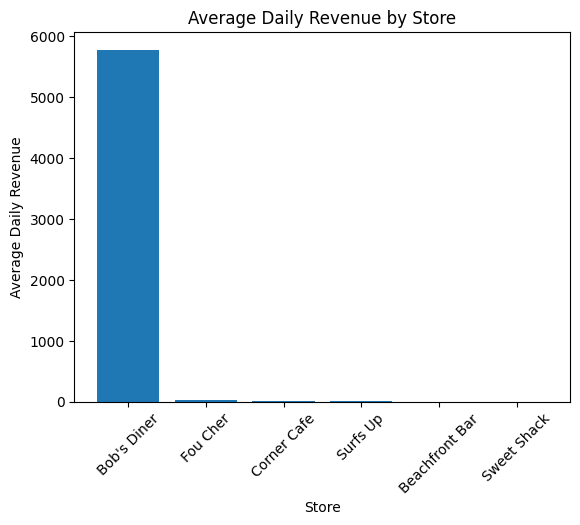

In [15]:
# Determine if the store with the highest sales volume is also making the most money per day

# Step -1: Find Store With Highest Sales Volume
volume_sales = merged_data.groupby('name_y')['item_count'].sum().reset_index()

volume_sales = volume_sales.sort_values('item_count', ascending=False)

print('\n\nvolume_sales:',volume_sales)

# step - 2 : Top store by volume:
print("Store with highest sales volume:")
print(volume_sales.iloc[0])


# step -3 : Calculate Revenue Per Day for Each Store
daily_sales = merged_data.groupby(['name_y','date'])['total_sales'].sum().reset_index()

# Now compute average revenue per day per store
avg_daily_sales = daily_sales.groupby('name_y')['total_sales'].mean().reset_index()

avg_daily_sales = avg_daily_sales.sort_values('total_sales', ascending=False)

print('\n\navg_daily_sales: ',avg_daily_sales)

# Top store by daily revenue:
print("\nStore with highest average daily revenue:")
print(avg_daily_sales.iloc[0])

# step 4- Compare Results

print("\nHighest volume store:", volume_sales.iloc[0]['name_y'])
print("\nHighest revenue per day store:", avg_daily_sales.iloc[0]['name_y'])

# step 5- Optional Visualization


plt.figure()
plt.bar(avg_daily_sales['name_y'], avg_daily_sales['total_sales'])
plt.xticks(rotation=45)
plt.xlabel("Store")
plt.ylabel("Average Daily Revenue")
plt.title("Average Daily Revenue by Store")
plt.show()


In [16]:
# Identify the most expensive item at each restaurant and find out its calorie count

# step 1- Find Most Expensive Item at Each Store
expensive_items = merged_data.loc[
    merged_data.groupby('name_y')['cost'].idxmax(),
      ['name_y', 'name_x', 'cost', 'kcal']
      ]

print('\nexpensive_items',expensive_items)


expensive_items             name_y                         name_x   cost  kcal
68  Beachfront Bar          Sweet Vegi Soft Drink   5.70   538
0      Bob's Diner              Sweet Fruity Cake  29.22   931
58     Corner Cafe                     Pike Lunch  26.37   653
82        Fou Cher  Blue Ribbon Fruity Vegi Lunch  53.98   881
8         Surfs Up                     Steak Meal  26.21   607
79     Sweet Shack  Blue Ribbon Frozen Milky Cake   7.70   636


# Part 2 #
   ## Forecasting using machine learning algorithms ##

In [17]:
# step 1 - Feature Engineering
date_sales['year'] = date_sales['date'].dt.year
date_sales['month'] = date_sales['date'].dt.month
date_sales['day'] = date_sales['date'].dt.day
date_sales['day_of_week'] = date_sales['date'].dt.dayofweek
date_sales['quarter'] = date_sales['date'].dt.quarter

# step 2- Features list:
features = ['year','month','day','day_of_week','quarter']
X = date_sales[features]
y = date_sales['total_sales']

# step 3- Train/Test Split
split_date = date_sales['date'].max() - pd.DateOffset(months=6)

train = date_sales[date_sales['date'] < split_date]
test = date_sales[date_sales['date'] >= split_date]

X_train = train[features]
y_train = train['total_sales']

X_test = test[features]
y_test = test['total_sales']


### Model 1 — Linear Regression

In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("\nLinear Regression RMSE:", lr_rmse)



Linear Regression RMSE: 2386.273963945839


### Model 2 — Random Forest

In [19]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("\nRandom Forest RMSE:", rf_rmse)



Random Forest RMSE: 834.810563166811


### Model 3 — XGBoost

In [20]:
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("\nXGBoost RMSE:", xgb_rmse)


XGBoost RMSE: 666.0434052982527


# Compare Model Performance

In [21]:
print("\nModel Comparison")
print("\nLinear Regression RMSE:", lr_rmse)
print("\nRandom Forest RMSE:", rf_rmse)
print("\nXGBoost RMSE:", xgb_rmse)


Model Comparison

Linear Regression RMSE: 2386.273963945839

Random Forest RMSE: 834.810563166811

XGBoost RMSE: 666.0434052982527


# Forecast Next Year

In [22]:

future_dates = pd.date_range(
      start= date_sales['date'].max()+pd.Timedelta(days=1),
      periods=365
      )

future = pd.DataFrame({'date':future_dates})

future['year'] = future['date'].dt.year
future['month'] = future['date'].dt.month
future['day'] = future['date'].dt.day
future['day_of_week'] = future['date'].dt.dayofweek
future['quarter'] = future['date'].dt.quarter


# Predict using best model

In [23]:
future['forecast_sales'] = xgb.predict(future[features])

#  Plot Forecast

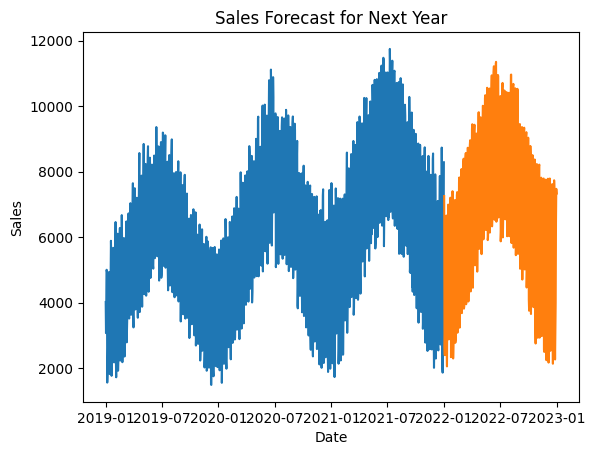

In [24]:
plt.figure()

plt.plot(date_sales['date'], date_sales['total_sales'])
plt.plot(future['date'], future['forecast_sales'])

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecast for Next Year")

plt.show()

### Deep Learning ###

                  # part 1 #

# Forecasting using deep learning algorithms:

In [25]:
# step 1 - Sort by date:
date_sales = date_sales.sort_values('date')

In [26]:
# step 2- Scale the Data (LSTM models perform better with normalized data)
scaler = MinMaxScaler()

sales_scaled = scaler.fit_transform(date_sales[['total_sales']])

In [27]:
# step 3- Create Time Series Sequences (Define a function to create input sequences)
def create_sequences(data, seq_length):

        X = []
        y = []

        for i in range(len(data) - seq_length):
            X.append(data[i:i+seq_length])
            y.append(data[i+seq_length])

        return np.array(X), np.array(y)

In [28]:
# Use 30 days of history to predict the next day

seq_length = 30
X, y = create_sequences(sales_scaled, seq_length)

In [29]:
# step 4- Define Train and Test Series (Use last 12 months as test data)
test_days = 365

X_train = X[:-test_days]
y_train = y[:-test_days]

X_test = X[-test_days:]
y_test = y[-test_days:]

In [30]:
# step 5-  Generate Synthetic Data (Augmentation)
noise = np.random.normal(0, 0.01, X_train.shape)

X_train_augmented = X_train + noise

In [31]:
# step 6- Build the LSTM Model

model_RELU = Sequential()

model_RELU.add(LSTM(50, activation='relu', input_shape=(seq_length,1)))
model_RELU.add(Dense(1))

model_RELU.compile(
       optimizer='adam',
      loss='mse'
      )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
# step 7- Train the Model

model_RELU.fit(
      X_train_augmented,
      y_train,
      epochs=20,
      batch_size=32
      )


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.1777
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0331
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0289
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0271
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0269
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0267
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0263
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0261
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0270
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0261
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0258
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0256
Epoch 13/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0247
Epoch 14/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0250
Epoch 15/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0238
Epoch 16/20
22/22 

In [33]:
# step 8- Make Predictions on Test Data

predictions = model_RELU.predict(X_test)

# Convert predictions back to original scale

predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [34]:
# step 9- Calculate MAPE

mape = mean_absolute_percentage_error(
      y_test_actual,
      predictions
      )

print("\nMAPE:", mape)
print("MAPE (%):", mape * 100)


MAPE: 0.20725915314164672
MAPE (%): 20.725915314164673


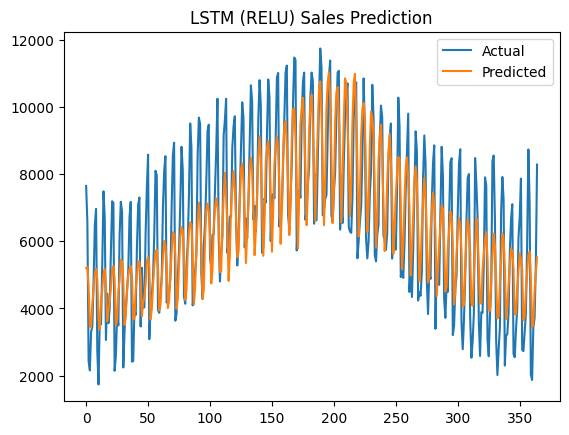

In [35]:
# step- 10: Plot Actual vs Predicted

plt.figure()

plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()

plt.title("LSTM (RELU) Sales Prediction")

plt.show()

In [36]:
# step 11: Train Model on Entire Series (train using all data to forecast future values)

model_RELU.fit(
       X,
       y,
       epochs=20,
       batch_size=32
      )

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0164
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0141
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0112
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0107
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0097
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0093
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0093
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0082
Epoch 9/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0082
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0085
Epoch 11/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0073
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0078
Epoch 13/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066
Epoch 14/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0062
Epoch 15/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0067
Epoch 16/20
34/34

In [37]:
# step - 12: Forecast Next 3 Months (Predict 90 days ahead)

future_predictions = []

last_sequence = sales_scaled[-seq_length:]

current_seq = last_sequence.reshape(1, seq_length, 1)

for i in range(90):


       pred = model_RELU.predict(current_seq)

       future_predictions.append(pred[0][0])

            # reshape prediction properly
       pred = pred.reshape(1,1,1)

       current_seq = np.append(
            current_seq[:,1:,:],
            pred,
            axis=1
            )

# Convert back to original scale

future_predictions = scaler.inverse_transform(
      np.array(future_predictions).reshape(-1,1)
      )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━

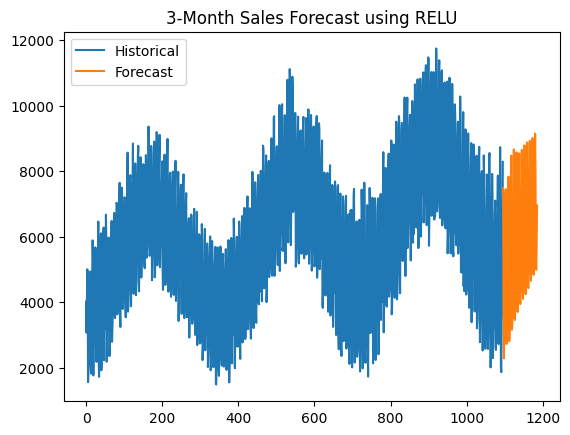

In [38]:
# step 13: Plot Forecast

plt.figure()

plt.plot(date_sales['total_sales'], label="Historical")

plt.plot(
      range(len(date_sales), len(date_sales)+90),
      future_predictions,
      label="Forecast"
      )

plt.legend()

plt.title("3-Month Sales Forecast using RELU")

plt.show()

# Develop another model (ELU) using the entire series for training, and use it to forecast for the next three months

  

In [39]:
 # Build ELU LSTM Model

model_ELU = Sequential()

model_ELU.add(
       LSTM(
           50,
            activation='elu',
            input_shape=(seq_length,1)
         )
   )

model_ELU.add(Dense(1))

model_ELU.compile(
      optimizer='adam',
      loss='mse'
   )


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
# Train Using Entire Dataset

model_ELU.fit(
      X_train_augmented,
      y_train,
      epochs=20,
      batch_size=32
      )


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0833
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0288
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0277
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0267
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0274
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0266
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0254
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0265
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0249
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0230
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0230
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0203
Epoch 13/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0163
Epoch 14/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0108
Epoch 15/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0104
Epoch 16/20
22/22 

In [41]:
# Make Predictions on Test Data

predictions = model_ELU.predict(X_test)

# Convert predictions back to original scale

predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [42]:
# Calculate MAPE

mape = mean_absolute_percentage_error(
      y_test_actual,
      predictions
      )

print("\nMAPE:", mape)
print("MAPE (%):", mape * 100)


MAPE: 0.15628807983484355
MAPE (%): 15.628807983484355


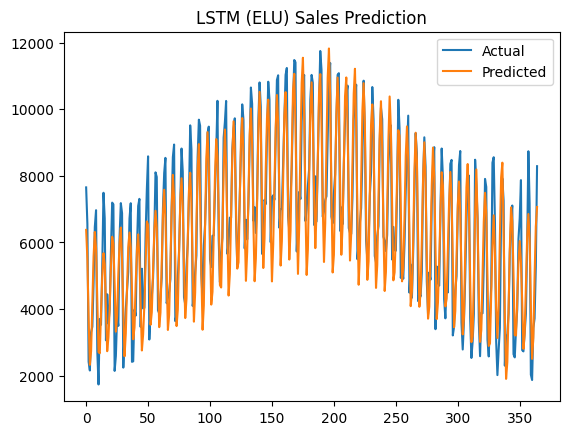

In [43]:
# Plot Actual vs Predicted

plt.figure()

plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()

plt.title("LSTM (ELU) Sales Prediction")

plt.show()

In [44]:
# rain Model on Entire Series (train using all data to forecast future values)

model_ELU.fit(
       X,
       y,
       epochs=20,
       batch_size=32
      )

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0088
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0082
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0078
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0083
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0079
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0076
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0069
Epoch 9/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0066
Epoch 11/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0066
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0067
Epoch 13/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0061
Epoch 14/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0068
Epoch 15/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0070
Epoch 16/20
34/34 

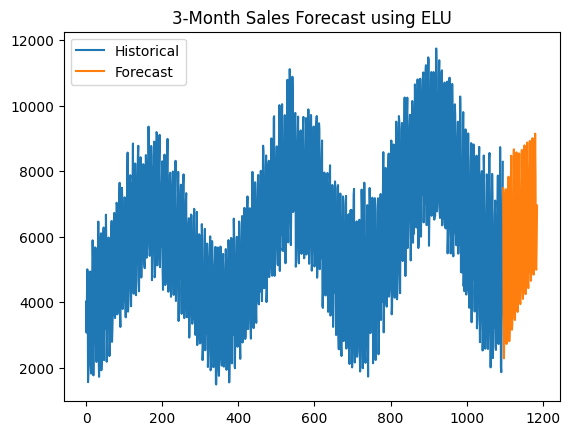

In [45]:
# Plot Forecast

plt.figure()

plt.plot(date_sales['total_sales'], label="Historical")

plt.plot(
      range(len(date_sales), len(date_sales)+90),
      future_predictions,
      label="Forecast"
      )

plt.legend()

plt.title("3-Month Sales Forecast using ELU")

plt.show()